In [51]:
import pickle as pkl
model=pkl.dump(model,open('model.pkl','wb'))
Transformer=pkl.dump(Transformer,open("Transformer.pkl","wb"))
colText=pkl.dump(colText,open('colText.pkl','wb'))
# colNumber=pkl.dump(colNum,open('colNum','wb'))

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import xgboost
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score,precision_score,accuracy_score,confusion_matrix,classification_report,recall_score
# from sklearn.
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer

In [3]:
fraud=pd.read_csv("Fraud Prediction training dataset.csv")

In [4]:
fraud

,step,customer,account age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0
...,...,...,...,...,...,...,...,...,...,...
594638,179,'C1753498738','3','F','28007','M1823072687','28007','es_transportation',20.53,0
594639,179,'C650108285','4','F','28007','M1823072687','28007','es_transportation',50.73,0
594640,179,'C123623130','2','F','28007','M349281107','28007','es_fashion',22.44,0
594641,179,'C1499363341','5','M','28007','M1823072687','28007','es_transportation',14.46,0


In [5]:
columnsToExclude=['customer','zipcodeOri','zipMerchant','step']
fraud=fraud.drop(columns=columnsToExclude)

In [7]:
colText=['merchant','gender','category']

In [8]:
colNumber=['account age', 'amount']

In [9]:
# convert these columns to string dtype
for catCols in ['account age','gender','merchant','category']:
    fraud[catCols]=fraud[catCols].astype(str)

In [ ]:
fraud.dtypes

In [ ]:
# # account_age to number
# fraud['account age']=pd.to_numeric(fraud["account age"],errors="coerce")

In [10]:
for cols in fraud.columns:
    if fraud[cols].dtype=="object":
        fraud[cols]=fraud[cols].str.replace("'","",regex=False).str.strip()
        fraud[cols]=fraud[cols].str.replace("es_","",regex=False).str.strip()

In [11]:
fraud


,account age,gender,merchant,category,amount,fraud
0,4,M,M348934600,transportation,4.55,0
1,2,M,M348934600,transportation,39.68,0
2,4,F,M1823072687,transportation,26.89,0
3,3,M,M348934600,transportation,17.25,0
4,5,M,M348934600,transportation,35.72,0
...,...,...,...,...,...,...
594638,3,F,M1823072687,transportation,20.53,0
594639,4,F,M1823072687,transportation,50.73,0
594640,2,F,M349281107,fashion,22.44,0
594641,5,M,M1823072687,transportation,14.46,0


In [19]:
fraud['account age']=pd.to_numeric(fraud['account age'],errors="coerce")

In [20]:
fraud.isnull().sum()

account age    0
gender         0
merchant       0
category       0
amount         0
fraud          0
dtype: int64

In [21]:
fraud['account age'].dtypes

dtype('float64')

In [22]:
fraud.dtypes

account age    float64
gender          object
merchant        object
category        object
amount         float64
fraud            int64
dtype: object

In [23]:
fraud

,account age,gender,merchant,category,amount,fraud
0,4.0,M,M348934600,transportation,4.55,0
1,2.0,M,M348934600,transportation,39.68,0
2,4.0,F,M1823072687,transportation,26.89,0
3,3.0,M,M348934600,transportation,17.25,0
4,5.0,M,M348934600,transportation,35.72,0
...,...,...,...,...,...,...
594638,3.0,F,M1823072687,transportation,20.53,0
594639,4.0,F,M1823072687,transportation,50.73,0
594640,2.0,F,M349281107,fashion,22.44,0
594641,5.0,M,M1823072687,transportation,14.46,0


In [24]:
colText

['merchant', 'gender', 'category']

In [ ]:
# for type in colNumber:
    # print(fraud[type].dtype)

In [ ]:
fraud.dtypes

In [25]:
fraud['account age']=fraud['account age'].fillna(fraud['account age'].median())

In [26]:
fraud.isnull().sum()

account age    0
gender         0
merchant       0
category       0
amount         0
fraud          0
dtype: int64

In [27]:
# handle outliers
for handleOut in fraud.columns:
    if handleOut not in colText and handleOut not in ["fraud"]:
        Q1=fraud[handleOut].quantile(0.25)
        Q3=fraud[handleOut].quantile(0.75)
        IQR=Q3-Q1

        Upper=Q3+1.5*IQR
        Lower=Q1-1.5*IQR

        

        count=fraud[(fraud[handleOut]<Lower) | (fraud[handleOut]>Upper)].shape[0]
        if count!=0:
            fraud[handleOut]=fraud[handleOut].clip(lower=Lower,upper=Upper)

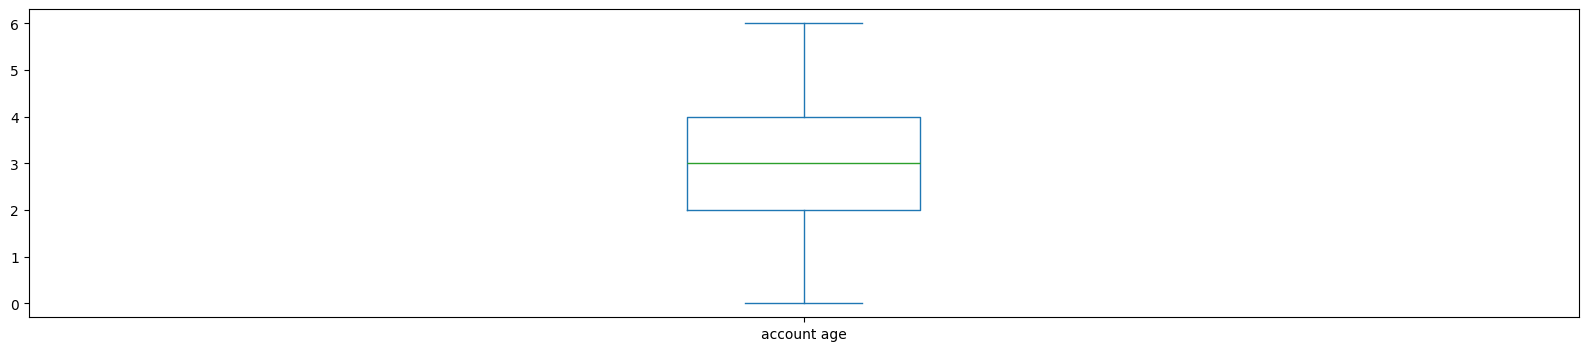

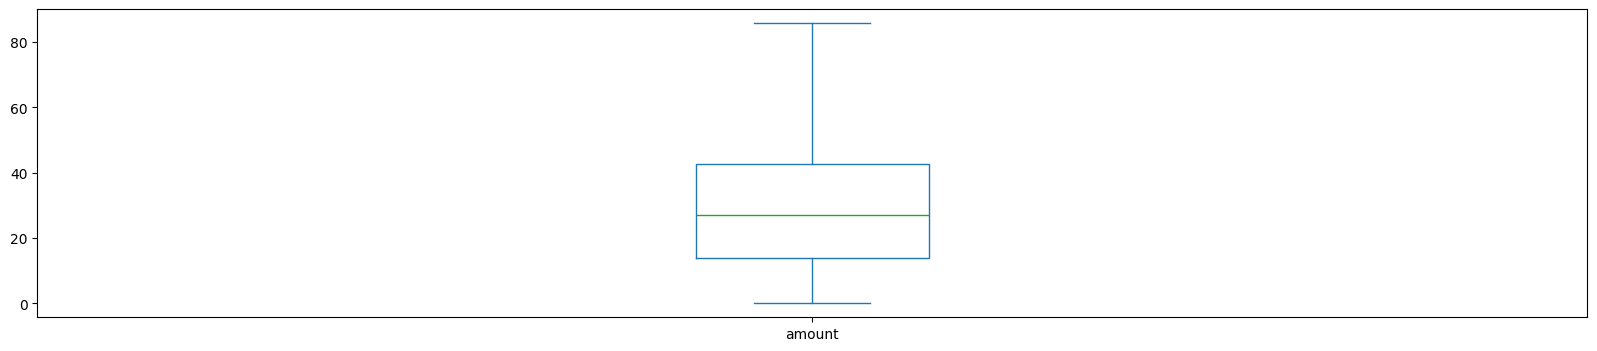

In [28]:
# check outliers 
for outlier in colNumber:
    plt.figure(figsize=(20,4))
    fraud[outlier].plot(kind="box")

In [29]:
fraud.to_csv("testSet.csv")

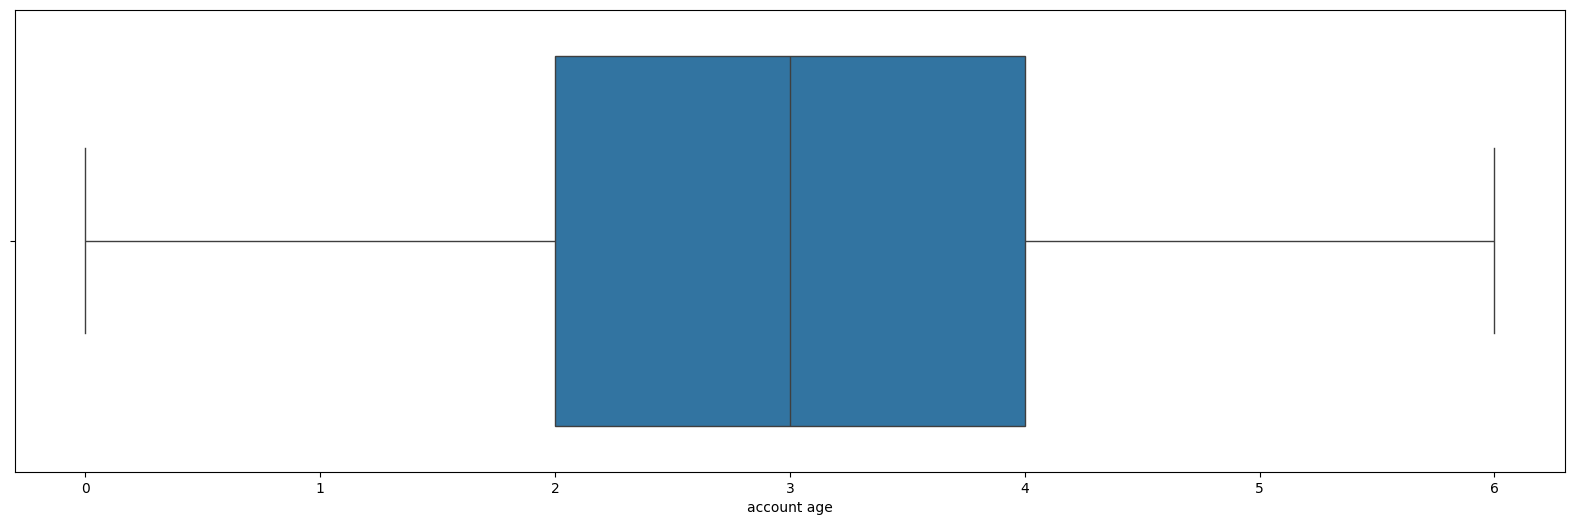

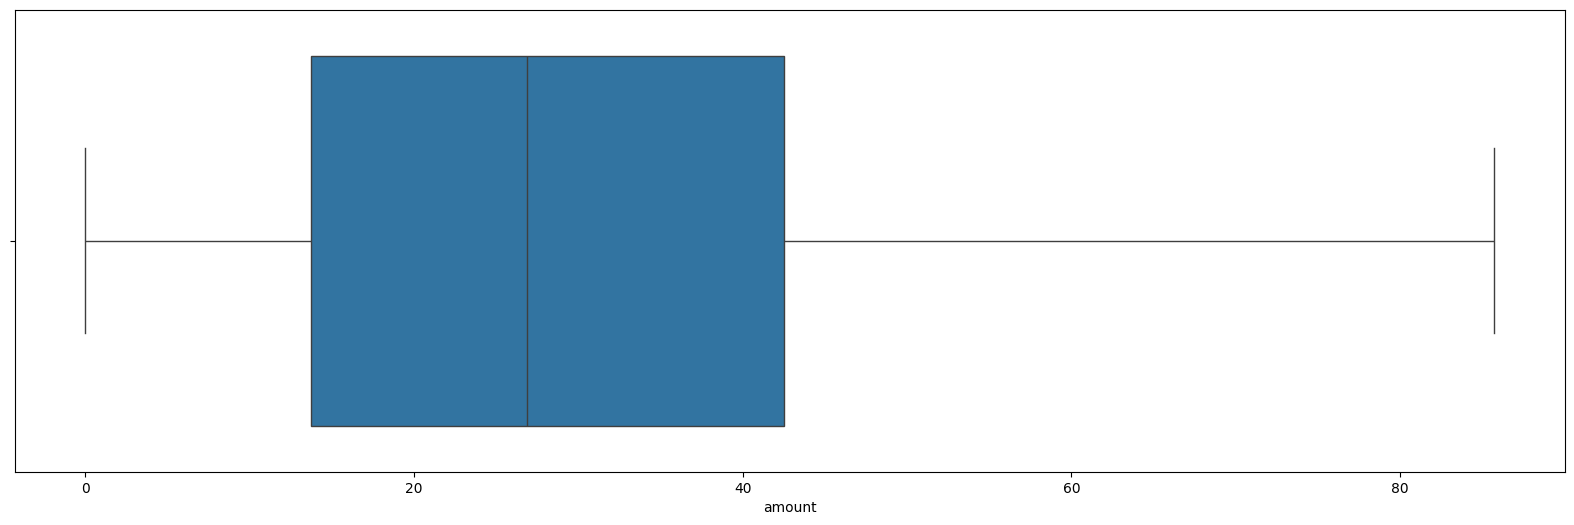

In [30]:
# chek outliers
for outliers in colNumber:
    if fraud[outliers].dtype!="object":
        plt.figure(figsize=(20,6))
        sns.boxplot(x=fraud[outliers])

In [31]:
fraud[colNumber].corrwith(fraud['fraud'])

account age   -0.004016
amount         0.253719
dtype: float64

<Axes: >

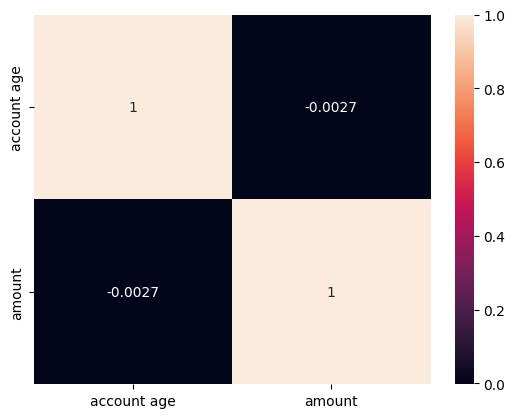

In [32]:
sns.heatmap(fraud[colNumber].corr(),annot=True)

In [38]:
# split data
x=fraud.drop(columns=['fraud'])
y=fraud['fraud']
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=.30,random_state=56)

In [ ]:
# columnsTobeincludedInPipeline=['merchant', 'gender', 'category','account age']

In [39]:
# Feature encoding
pipelineText=Pipeline(

    [("encode",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]
)


Transformer=ColumnTransformer(
    [("encoding",pipelineText,colText)],
    remainder="passthrough"
)

In [40]:
xTrain

,account age,gender,merchant,category,amount
563352,3.0,M,M1823072687,transportation,39.13
217063,3.0,M,M1053599405,health,85.74
33978,3.0,M,M348934600,transportation,5.70
25491,5.0,M,M348934600,transportation,9.26
485513,1.0,M,M348934600,transportation,56.82
...,...,...,...,...,...
472059,4.0,M,M1823072687,transportation,2.55
435322,3.0,F,M348934600,transportation,52.00
505250,5.0,M,M348934600,transportation,8.45
134336,1.0,F,M348934600,transportation,9.26


In [41]:
# encode .xTrain
xTrain=Transformer.fit_transform(xTrain)

In [ ]:
# fraud

In [42]:
colNumber

['account age', 'amount']

In [43]:
# Encode xTest 
xTest=Transformer.transform(xTest)

In [44]:
model = XGBClassifier(
    n_estimators          = 1000,
    learning_rate         = 0.1,
    max_depth             = 5,
    reg_alpha             = 0.1,
    reg_lambda            = 0.1,
    # scale_pos_weight      = 3.0,  
    # eval_metric           = "logloss",
    # early_stopping_rounds = 50
)

model.fit(
    xTrain, yTrain,
 
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [45]:
# preddiction
predict=model.predict(xTest)

In [46]:
predict

array([0, 0, 0, ..., 0, 0, 0], shape=(178393,))

In [47]:
# extract classification report
report=classification_report(yTest,predict,target_names=model.classes_,output_dict=True)

In [48]:
report

{np.int64(0): {'precision': 0.9964034082528733,
  'recall': 0.9966069381872652,
  'f1-score': 0.996505162827641,
  'support': 176242.0},
 np.int64(1): {'precision': 0.7172576832151301,
  'recall': 0.7052533705253371,
  'f1-score': 0.7112048757618378,
  'support': 2151.0},
 'accuracy': 0.9930938994243048,
 'macro avg': {'precision': 0.8568305457340017,
  'recall': 0.8509301543563011,
  'f1-score': 0.8538550192947394,
  'support': 178393.0},
 'weighted avg': {'precision': 0.9930375673591377,
  'recall': 0.9930938994243048,
  'f1-score': 0.9930651123913652,
  'support': 178393.0}}

In [49]:
reportFrame=pd.DataFrame(report)

In [50]:
reportFrame.transpose()

,precision,recall,f1-score,support
0,0.996403,0.996607,0.996505,176242.000000
1,0.717258,0.705253,0.711205,2151.000000
accuracy,0.993094,0.993094,0.993094,0.993094
macro avg,0.856831,0.850930,0.853855,178393.000000
weighted avg,0.993038,0.993094,0.993065,178393.000000
